In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df=pd.read_csv("Rajshahi-Srimongals.csv")
df=df[df["Year"]<2019]

In [3]:
dff=df.copy()

In [4]:


data_raj=dff[dff['Region']=='Rajshahi']
data_sri=dff[dff['Region']=='Srimongal']


In [5]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [6]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
611,28.1,30.7,31.3,30.2


# Rajshahi MLP

In [7]:
import math 



n=len(df_raj)

train_end=math.floor(n*0.80)


train_raj=df_raj.iloc[:train_end]
val_raj=df_raj.iloc[train_end:]

X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-10']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-10']]


In [8]:

scaler_raj = StandardScaler()
X_train_raj_scaled = scaler_raj.fit_transform(X_train_raj)
X_val_raj_scaled = scaler_raj.transform(X_val_raj)


modelr = Sequential()
modelr.add(Dense(50, activation='relu', input_shape=(X_train_raj_scaled.shape[1],)))
modelr.add(BatchNormalization())
modelr.add(Dropout(0.2))
modelr.add(Dense(30, activation='relu'))
modelr.add(Dense(16, activation='relu'))
modelr.add(Dense(1, activation='linear'))  


opt = Adam(learning_rate=0.001)
modelr.compile(optimizer=opt, loss='mse', metrics=['mae'])


es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


history = modelr.fit(
    X_train_raj_scaled, y_train_raj,
    validation_data=(X_val_raj_scaled, y_val_raj),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=0
)





In [9]:
y_raj_pred = modelr.predict(X_val_raj_scaled)
mae_raj=round(mean_absolute_error(y_val_raj,y_raj_pred),3)
mse_raj=mean_squared_error(y_val_raj,y_raj_pred)
rmse_raj=round(mse_raj**0.5,3)
r2_raj=round(r2_score(y_val_raj,y_raj_pred),2)


print("\nRAJSHAHI\n")
print(f"MAE: {mae_raj}\nRMSE: {rmse_raj}\nR2 SCORE: {r2_raj}")

42/42 [==============================] - 0s 2ms/step

RAJSHAHI

MAE: 0.876
RMSE: 1.142
R2 SCORE: 0.95


In [10]:
from sklearn.linear_model import LinearRegression

y_val_raj_reshaped = np.array(y_val_raj).reshape(-1, 1)
y_raj_pred_reshaped = np.array(y_raj_pred).reshape(-1, 1)

lin = LinearRegression()
lin.fit(y_val_raj_reshaped, y_raj_pred_reshaped)

m_raj = lin.coef_[0][0]    
c_raj = lin.intercept_[0]    
r2_raj = lin.score(y_val_raj_reshaped, y_raj_pred_reshaped)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_13480\2140514160.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_raj.min(), y_val_raj.max()],


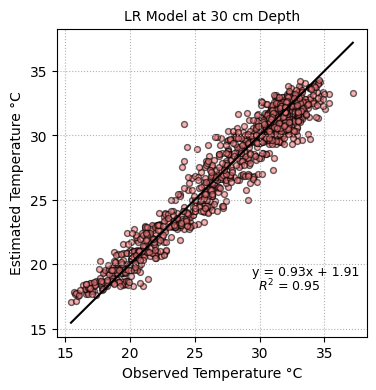

In [11]:
y_val_rajj= y_val_raj[400:1200]
y_raj_predd = y_raj_pred[400:1200]
plt.figure(figsize=(4,4))
plt.scatter(y_val_raj, y_raj_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r-', lw=1.5, label="1:1 line",c='black')

x_vals = np.linspace(y_val_raj.min(), y_val_raj.max(), 100)
#plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line",c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()

# Srimongal MLP 

In [23]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)

train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:]


In [24]:
val_sri.shape

(1315, 4)

In [25]:
X_train_sri = train_sri[['Temperature']]
y_train_sri = train_sri[['ST-10']]

X_val_sri = val_sri[['Temperature']]
y_val_sri = val_sri[['ST-10']]



In [26]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_13480\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


In [28]:

scaler_sri = StandardScaler()
X_train_sri_scaled = scaler_sri.fit_transform(X_train_sri)
X_val_sri_scaled = scaler_sri.transform(X_val_sri)


models = Sequential()
models.add(Dense(50, activation='relu', input_shape=(X_train_sri_scaled.shape[1],)))
models.add(BatchNormalization())
models.add(Dropout(0.2))
models.add(Dense(30, activation='relu'))
models.add(Dense(16, activation='relu'))
models.add(Dense(1, activation='linear'))  


opt = Adam(learning_rate=0.001)
models.compile(optimizer=opt, loss='mse', metrics=['mae'])


es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


history_sri = models.fit(
    X_train_sri_scaled, y_train_sri,
    validation_data=(X_val_sri_scaled, y_val_sri),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=0
)


In [29]:
y_sri_pred = models.predict(X_val_sri_scaled)
mae_sri=round(mean_absolute_error(y_val_sri,y_sri_pred),3)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
rmse_sri=round(mse_sri**0.5,3)
r2_sri=round(r2_score(y_val_sri,y_sri_pred),2)


print("\nSRIMONGAL\n")
print(f"MAE: {mae_sri}\nRMSE: {rmse_sri}\nR2 SCORE: {r2_sri}")

42/42 [==============================] - 0s 1ms/step

SRIMONGAL

MAE: 0.827
RMSE: 1.17
R2 SCORE: 0.92


In [30]:
from sklearn.linear_model import LinearRegression

y_val_sri_reshaped = np.array(y_val_sri).reshape(-1, 1)
y_sri_pred_reshaped = np.array(y_sri_pred).reshape(-1, 1)

lin = LinearRegression()
lin.fit(y_val_sri_reshaped, y_sri_pred_reshaped)

m_sri = lin.coef_[0][0]    
c_sri = lin.intercept_[0]    


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_13480\782796555.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_sri.min(), y_val_sri.max()],


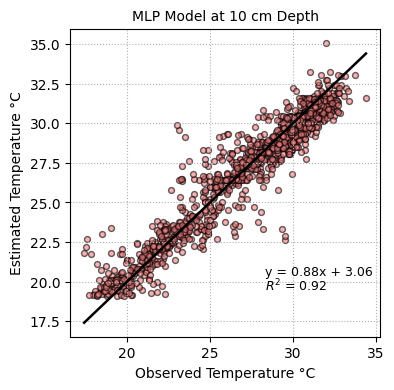

In [31]:

plt.figure(figsize=(4,4))
plt.scatter(y_val_sri, y_sri_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r-', lw=1.8, label="1:1 line",c='BLACK')

x_vals_sri = np.linspace(y_val_sri.min(), y_val_sri.max(), 100)
#plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line" ,c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.63, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('MLP Model at 10 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()
